In [405]:
import pandas as pd
import numpy as np
from rapidfuzz import process, fuzz
import matplotlib.pyplot as plt

In [406]:
df=pd.read_csv("train.csv")
display(df)


,carID,Brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
0,69512,VW,Golf,2016.0,22290,Semi-Auto,28421.0,Petrol,NaN,11.417268,2.0,63.0,4.000000,0.0
1,53000,Toyota,Yaris,2019.0,13790,Manual,4589.0,Petrol,145.0,47.900000,1.5,50.0,1.000000,0.0
2,6366,Audi,Q2,2019.0,24990,Semi-Auto,3624.0,Petrol,145.0,40.900000,1.5,56.0,4.000000,0.0
3,29021,Ford,FIESTA,2018.0,12500,anual,9102.0,Petrol,145.0,65.700000,1.0,50.0,-2.340306,0.0
4,10062,BMW,2 Series,2019.0,22995,Manual,1000.0,Petrol,145.0,42.800000,1.5,97.0,3.000000,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75968,37194,Mercedes,C Class,2015.0,13498,Manual,14480.0,etrol,125.0,53.300000,2.0,78.0,0.000000,0.0
75969,6265,Audi,Q3,2013.0,12495,Semi-Auto,52134.0,Diesel,200.0,47.900000,2.0,38.0,2.000000,0.0
75970,54886,Toyota,Aygo,2017.0,8399,Automatic,11304.0,Petrol,145.0,67.000000,1.0,57.0,3.000000,0.0
75971,860,Audi,Q3,2015.0,12990,Manual,69072.0,iesel,125.0,60.100000,2.0,74.0,2.000000,0.0


In [407]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 75973 entries, 0 to 75972
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   carID           75973 non-null  int64  
 1   Brand           74452 non-null  object 
 2   model           74456 non-null  object 
 3   year            74482 non-null  float64
 4   price           75973 non-null  int64  
 5   transmission    74451 non-null  object 
 6   mileage         74510 non-null  float64
 7   fuelType        74462 non-null  object 
 8   tax             68069 non-null  float64
 9   mpg             68047 non-null  float64
 10  engineSize      74457 non-null  float64
 11  paintQuality%   74449 non-null  float64
 12  previousOwners  74423 non-null  float64
 13  hasDamage       74425 non-null  float64
dtypes: float64(8), int64(2), object(4)
memory usage: 8.1+ MB


In [408]:
df.describe()

,carID,year,price,mileage,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
count,75973.000000,74482.000000,75973.000000,74510.000000,68069.000000,68047.000000,74457.000000,74449.000000,74423.000000,74425.0
mean,37986.000000,2017.096611,16881.889553,23004.184088,120.329078,55.152666,1.660136,64.590667,1.994580,0.0
std,21931.660338,2.208704,9736.926322,22129.788366,65.521176,16.497837,0.573462,21.021065,1.472981,0.0
min,0.000000,1970.000000,450.000000,-58540.574478,-91.121630,-43.421768,-0.103493,1.638913,-2.345650,0.0
25%,18993.000000,2016.000000,10200.000000,7423.250000,125.000000,46.300000,1.200000,47.000000,1.000000,0.0
50%,37986.000000,2017.000000,14699.000000,17300.000000,145.000000,54.300000,1.600000,65.000000,2.000000,0.0
75%,56979.000000,2019.000000,20950.000000,32427.500000,145.000000,62.800000,2.000000,82.000000,3.000000,0.0
max,75972.000000,2024.121759,159999.000000,323000.000000,580.000000,470.800000,6.600000,125.594308,6.258371,0.0


In [409]:
df["carID"].duplicated().any()
#não há IDs duplicados então vou troná-los em indices

np.False_

In [410]:
def carID_como_index(df):
    df = df.copy()
    df = df.set_index("carID")
    return df

df=carID_como_index(df)
display(df)

,Brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
carID,,,,,,,,,,,,,
69512,VW,Golf,2016.0,22290,Semi-Auto,28421.0,Petrol,NaN,11.417268,2.0,63.0,4.000000,0.0
53000,Toyota,Yaris,2019.0,13790,Manual,4589.0,Petrol,145.0,47.900000,1.5,50.0,1.000000,0.0
6366,Audi,Q2,2019.0,24990,Semi-Auto,3624.0,Petrol,145.0,40.900000,1.5,56.0,4.000000,0.0
29021,Ford,FIESTA,2018.0,12500,anual,9102.0,Petrol,145.0,65.700000,1.0,50.0,-2.340306,0.0
10062,BMW,2 Series,2019.0,22995,Manual,1000.0,Petrol,145.0,42.800000,1.5,97.0,3.000000,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
37194,Mercedes,C Class,2015.0,13498,Manual,14480.0,etrol,125.0,53.300000,2.0,78.0,0.000000,0.0
6265,Audi,Q3,2013.0,12495,Semi-Auto,52134.0,Diesel,200.0,47.900000,2.0,38.0,2.000000,0.0
54886,Toyota,Aygo,2017.0,8399,Automatic,11304.0,Petrol,145.0,67.000000,1.0,57.0,3.000000,0.0


In [411]:
df["Brand"].unique()

array(['VW', 'Toyota', 'Audi', 'Ford', 'BMW', 'Skoda', 'Opel', 'Mercedes',
       'FOR', 'mercedes', 'Hyundai', 'w', 'ord', 'MW', 'bmw', nan,
       'yundai', 'BM', 'Toyot', 'udi', 'Ope', 'AUDI', 'V', 'opel', 'pel',
       'For', 'pe', 'Mercede', 'audi', 'MERCEDES', 'OPEL', 'koda', 'FORD',
       'Hyunda', 'W', 'Aud', 'vw', 'hyundai', 'skoda', 'ford', 'TOYOTA',
       'ercedes', 'oyota', 'toyota', 'SKODA', 'Skod', 'HYUNDAI', 'kod',
       'v', 'for', 'SKOD', 'aud', 'KODA', 'PEL', 'yunda', 'or', 'UDI',
       'OYOTA', 'HYUNDA', 'mw', 'OPE', 'mercede', 'ERCEDES', 'ercede',
       'TOYOT', 'MERCEDE', 'ORD', 'ud', 'ope', 'AUD', 'hyunda', 'skod',
       'toyot'], dtype=object)

In [412]:
df["Brand"].value_counts()

Brand
Ford        14808
Mercedes    10754
VW           9780
Opel         8645
BMW          6968
            ...  
OYOTA           2
SKOD            1
TOYOT           1
skod            1
toyot           1
Name: count, Length: 72, dtype: int64

In [413]:
df[df["Brand"].isna()]

,Brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
carID,,,,,,,,,,,,,
66591,NaN,T-Roc,2018.0,23000,Semi-Auto,584.0,Petrol,150.0,41.5,2.0,79.0,1.0,0.0
5034,NaN,A3,2016.0,11871,Manual,52519.0,Diesel,20.0,72.4,1.6,60.0,2.0,0.0
33153,NaN,I20,2020.0,13966,MANUAL,3500.0,Petrol,145.0,47.9,1.0,41.0,2.0,0.0
45338,NaN,CL Class,2020.0,54995,Semi-Auto,NaN,Petrol,145.0,33.2,2.0,61.0,4.0,0.0
66712,NaN,POLO,2016.0,8650,Manual,32800.0,Petrol,20.0,60.1,1.0,54.0,4.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
72615,NaN,Golf,2015.0,11750,Manual,79000.0,Diesel,20.0,67.3,2.0,68.0,0.0,0.0
3436,NaN,Q5,2015.0,21995,Semi-Auto,18188.0,Diesel,200.0,47.1,2.0,84.0,3.0,0.0
7392,NaN,A5,2019.0,31490,Automatic,10.0,Petrol,145.0,39.8,2.0,70.0,1.0,0.0


In [414]:
def HELPER_marca_correta(marca, marcas_dict, threshold):
    if not isinstance(marca, str) or marca.strip() == "":
        return marca

    marca_lower = marca.lower().strip()

    result = process.extractOne(
        marca_lower,
        marcas_dict.keys(),
        scorer=fuzz.token_sort_ratio
    )
    
    #result = (match, score, index)
    #ex: match = toyota, score = 94.5, index = 1 (qual das marcas no dicionário é mais semelhante)

    if result is None:
        return marca

    match_lower, score, _ = result
    return marcas_dict[match_lower] if score >= threshold else marca

def fuzzy_marcas(df, threshold=50):
    df=df.copy()

    valid_brands = ["VW", "Toyota", "Audi", "Ford", "BMW", "Opel", "Skoda", "Mercedes", "Hyundai"]
    brands_dict = {BRAND.lower(): BRAND for BRAND in valid_brands}

    df["Brand"] = df["Brand"].apply(lambda x: HELPER_marca_correta(x, brands_dict, threshold))
    return df

In [415]:
df=fuzzy_marcas(df)
df["Brand"].unique()

array(['VW', 'Toyota', 'Audi', 'Ford', 'BMW', 'Skoda', 'Opel', 'Mercedes',
       'Hyundai', nan], dtype=object)

In [416]:
df["Brand"].value_counts()

Brand
Ford        16063
Mercedes    11674
VW          10385
Opel         9352
BMW          7392
Audi         7325
Toyota       4622
Skoda        4303
Hyundai      3336
Name: count, dtype: int64

In [417]:
df["model"].unique()

array([' Golf', ' Yaris', ' Q2', ' FIESTA', ' 2 Series', '3 Series',
       ' A3', ' Octavia', ' Passat', ' Focus', ' Insignia', ' A Clas',
       ' Q3', ' Fabia', ' A Class', ' Ka+', ' 3 Series', ' GLC Class',
       ' I30', ' C Class', ' Polo', ' E Class', ' C Clas', ' Q5', ' Up',
       ' Fiesta', ' C-HR', ' Mokka X', ' Corsa', ' Astra', ' TT',
       ' 5 Series', ' Aygo', ' 4 Series', ' SLK', ' Viva', ' T-Roc',
       'Focus', ' EcoSport', ' Tucson', ' EcoSpor', nan, ' X-CLASS',
       ' CL Class', ' IX20', ' i20', ' Rapid', ' a1', ' Auris', ' sharan',
       ' I20', ' Adam', ' X3', ' A8', ' GLS Class', ' B-MAX', ' A4',
       ' Kona', ' I10', ' A1', ' Mokka', ' fiesta', ' S-MAX', ' X2',
       ' Crossland X', ' Tiguan', ' A5', ' GLE Class', ' C CLASS',
       ' mokka x', ' Zafira', ' Ioniq', ' A6', ' Mondeo', ' Yeti Outdoor',
       ' X1', 'POLO', ' INSIGNIA', ' Scala', ' S Class', ' 1 Series',
       ' Kamiq', ' Kuga', ' Tourneo Connect', ' Q7', ' GLA Class',
       ' Arteon', ' 

In [418]:
len(df["model"].unique())

736

In [419]:
# group models by brand
grouped = df.groupby("Brand")["model"].value_counts()

display(grouped["Hyundai"])


model
 Tucson      821
 I10         671
 I30         352
 I20         307
 Kona        213
 Ioniq       185
 Santa Fe    135
 IX20        129
 I40          78
 IX35         74
 I800         72
 i10          20
 Tucso        18
 TUCSON       17
 tucson       16
 I1           15
Tucson        15
I10           13
 I3            9
 Santa F       8
 i30           8
 Ioni          7
 i20           7
 Getz          6
Ioniq          6
Kona           6
I20            5
I30            5
 I2            4
 SANTA FE      4
 I80           3
 IX2           3
 ix20          3
 kona          3
 santa fe      3
Santa Fe       3
 IONIQ         2
 KONA          2
 Kon           2
 ix35          2
IX20           2
IX35           2
 Accent        1
 KON           1
 TUCSO         1
 Terracan      1
 Veloste       1
 i40           1
 ioniq         1
I40            1
IONIQ          1
Tucso          1
Name: count, dtype: int64

In [420]:
"""Optained through meticulous ChatGPT prompt engineering"""
valid_models = {
    "Audi": [
        "A1", "A2", "A3", "A4", "A5", "A6", "A7", "A8",
        "Q2", "Q3", "Q5", "Q7", "Q8",
        "TT", "T", "R8",
        "S3", "S4", "S5", "S8",
        "RS3", "RS4", "RS5", "RS6",
        "SQ5", "SQ7"
    ],

    "Ford": [
        "FOCUS", "FIESTA", "MONDEO", "KA", "KA+", "FUSION",
        "KUGA", "ECOSPORT", "EDGE", "PUMA",
        "CMAX", "BMAX", "SMAX", "GALAXY",
        "GRANDCMAX", "TOURNEOCONNECT", "GRANDTOURNEOCONNECT", "TOURNEOCUSTOM",
        "MUSTANG", "RANGER", "ESCORT", "STREETKA"
    ],

    "Mercedes": [
        "ACLASS", "BCLASS", "CCLASS", "ECLASS", "SCLASS",
        "GLA", "GLB", "GLC", "GLE", "GLS", "GCLASS", "GLCLASS", "MCLASS",
        "CLA", "CLS", "SL", "SLK", "CLK",
        "VCLASS", "XCLASS", "CLC"
    ],

    "VW": [
        "GOLF", "POLO", "PASSAT", "JETTA", "ARTEON", "SCIROCCO", "BEETLE",
        "UP", "GOL", "FOX",
        "TIGUAN", "TIGUANALLSPACE", "TROC", "TCROSS", "TOUAREG",
        "TOURAN", "SHARAN", "CADDY", "CADDYMAXI", "CADDYMAXILIFE",
        "CARAVELLE", "CALIFORNIA", "SHUTTLE",
        "AMAROK", "GOLFSV", "CC"
    ],

    "Opel": [
        "CORSA", "ASTRA", "INSIGNIA", "VECTRA",
        "MOKKA", "MOKKAX", "CROSSLAND", "CROSSLANDX",
        "GRANDLAND", "GRANDLANDX", "ANTARA",
        "ZAFIRA", "ZAFIRATOURER", "MERIVA", "COMBOLIFE", "VIVARO",
        "ADAM", "AGILA", "VIVA",
        "TIGRA", "GTC", "CASCADA", "AMPERA"
    ],

    "BMW": [
        "1SERIES", "2SERIES", "3SERIES", "4SERIES",
        "5SERIES", "6SERIES", "7SERIES", "8SERIES",
        "X1", "X2", "X3", "X4", "X5", "X6", "X7",
        "M2", "M3", "M4", "M5", "M6",
        "Z3", "Z4",
        "I3", "I4", "I8"
    ],

    "Toyota": [
        "YARIS", "AYGO", "AURIS", "COROLLA", "AVENSIS", "CAMRY", "PRIUS",
        "CHR", "RAV4", "LANDCRUISER", "URBANCRUISER",
        "VERSO", "VERSOS", "PROACEVERSO",
        "HILUX", "GT86", "SUPRA", "IQ"
    ],

    "Skoda": [
        "FABIA", "OCTAVIA", "SUPERB", "RAPID", "SCALA",
        "KODIAQ", "KAROQ", "KAMIQ", "YETI", "YETIOUTDOOR",
        "CITIGO", "ROOMSTER"
    ],

    "Hyundai": [
        "I10", "I20", "I30", "I40", "ACCENT", "GETZ",
        "KONA", "TUCSON", "SANTAFE", "IX20", "IX35",
        "I800", "IONIQ", "VELOSTER", "TERRACAN"
    ]
}


In [421]:
def HELPER_normalize_models(df):
    df = df.copy()
    
    df["model"] = (
        df["model"]
        .astype(str)
        .str.upper()
        .str.replace("-", "", regex=False)       # remove hyphens
        .str.replace(r"\s+", "", regex=True)     # remove all whitespace
        .replace(["", "NAN", "NONE"], None)
    )
    return df


In [422]:
def HELPER_modelo_correto(model, brand, valid_models_dict, threshold):
    if not model or model.strip() == "":
        return None

    if not brand:
        return model
    
    # Skip unknown brands
    if brand not in valid_models_dict:
        return model
    
    valid_list = valid_models_dict[brand]

    result = process.extractOne(
        model,
        valid_list,
        scorer=fuzz.token_sort_ratio
    )

    if result is None:
        return model    

    model_name, score, _ = result
    return model_name if score >= threshold else None

def fuzzy_modelos(df, valid_models_dict, threshold=60):
    df = HELPER_normalize_models(df)
    
    df["model"] = df.apply(
        lambda row: HELPER_modelo_correto(row["model"], row["Brand"], valid_models_dict, threshold),
        axis=1
    )
    return df


In [423]:
len(df["model"].unique())
df[df["model"].isna()]

,Brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
carID,,,,,,,,,,,,,
30317,Ford,NaN,2019.0,9999,Manual,10000.0,Petrol,145.0,47.9,0.0,61.0,3.0,0.0
28739,Ford,NaN,2015.0,7099,Manual,74176.0,Diesel,NaN,NaN,1.5,84.0,2.0,NaN
63868,Opel,NaN,2016.0,8695,Manual,39460.0,Petrol,125.0,50.4,1.4,99.0,1.0,0.0
18304,Ford,NaN,2016.0,9632,Manual,18814.0,Petrol,20.0,62.8,1.0,74.0,NaN,0.0
65285,Opel,NaN,2016.0,6999,Manual,45367.0,Petrol,30.0,55.4,1.4,41.0,2.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
72991,VW,NaN,2018.0,17391,Manual,17987.0,Petrol,145.0,46.3,1.4,58.0,2.0,NaN
29299,Ford,NaN,2017.0,19289,anual,28492.0,Diesel,145.0,56.5,2.0,85.0,1.0,0.0
56250,Opel,NaN,2019.0,15495,Manual,3129.0,Petrol,145.0,39.2,1.4,49.0,0.0,NaN


In [424]:
unique_models_per_brand = df.groupby("Brand")["model"].nunique()
print(unique_models_per_brand)

Brand
Audi         62
BMW          91
Ford         92
Hyundai      52
Mercedes    103
Opel         90
Skoda        61
Toyota       68
VW          114
Name: model, dtype: int64


In [425]:
df=normalize_models(df)
df=fuzzy_modelos(df, valid_models)
df[df["model"].isna()]

,Brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
carID,,,,,,,,,,,,,
30317,Ford,None,2019.0,9999,Manual,10000.0,Petrol,145.0,47.9,0.0,61.0,3.0,0.0
28739,Ford,None,2015.0,7099,Manual,74176.0,Diesel,NaN,NaN,1.5,84.0,2.0,NaN
63868,Opel,None,2016.0,8695,Manual,39460.0,Petrol,125.0,50.4,1.4,99.0,1.0,0.0
18304,Ford,None,2016.0,9632,Manual,18814.0,Petrol,20.0,62.8,1.0,74.0,NaN,0.0
65285,Opel,None,2016.0,6999,Manual,45367.0,Petrol,30.0,55.4,1.4,41.0,2.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
72991,VW,None,2018.0,17391,Manual,17987.0,Petrol,145.0,46.3,1.4,58.0,2.0,NaN
29299,Ford,None,2017.0,19289,anual,28492.0,Diesel,145.0,56.5,2.0,85.0,1.0,0.0
56250,Opel,None,2019.0,15495,Manual,3129.0,Petrol,145.0,39.2,1.4,49.0,0.0,NaN


In [426]:
unique_models_per_brand = df.groupby("Brand")["model"].nunique()
print(unique_models_per_brand)

Brand
Audi        26
BMW         24
Ford        22
Hyundai     15
Mercedes    13
Opel        23
Skoda       12
Toyota      18
VW          26
Name: model, dtype: int64


In [427]:
def inferir_marca_com_modelo(df, valid_models_dict):
    df = df.copy()

 # Build a mapping of models → their most frequent (mode) brand in the dataset
    model_to_brand = (
        df[df["Brand"].notna()]
        .groupby("model")["Brand"]
        .agg(lambda x: x.mode().iloc[0] if not x.mode().empty else None)
        .to_dict()
    )

    df["Brand"] = df.apply(
    lambda row: (
        row["Brand"]
        if pd.notna(row["Brand"])
        else model_to_brand.get(row["model"], None)
    ),
    axis=1
    )

    return df


In [428]:
df[df["Brand"].isna()]

,Brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
carID,,,,,,,,,,,,,
66591,NaN,TROC,2018.0,23000,Semi-Auto,584.0,Petrol,150.0,41.5,2.0,79.0,1.0,0.0
5034,NaN,A3,2016.0,11871,Manual,52519.0,Diesel,20.0,72.4,1.6,60.0,2.0,0.0
33153,NaN,I20,2020.0,13966,MANUAL,3500.0,Petrol,145.0,47.9,1.0,41.0,2.0,0.0
45338,NaN,CLCLASS,2020.0,54995,Semi-Auto,NaN,Petrol,145.0,33.2,2.0,61.0,4.0,0.0
66712,NaN,POLO,2016.0,8650,Manual,32800.0,Petrol,20.0,60.1,1.0,54.0,4.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
72615,NaN,GOLF,2015.0,11750,Manual,79000.0,Diesel,20.0,67.3,2.0,68.0,0.0,0.0
3436,NaN,Q5,2015.0,21995,Semi-Auto,18188.0,Diesel,200.0,47.1,2.0,84.0,3.0,0.0
7392,NaN,A5,2019.0,31490,Automatic,10.0,Petrol,145.0,39.8,2.0,70.0,1.0,0.0


In [429]:
df=inferir_marca_com_modelo(df, valid_models)
df[df["Brand"].isna()]

,Brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
carID,,,,,,,,,,,,,
45338,None,CLCLASS,2020.0,54995,Semi-Auto,NaN,Petrol,145.0,33.2,2.0,61.0,4.0,0.0
16342,None,None,2017.0,8600,MANUAL,28820.0,Diesel,0.0,74.4,1.5,NaN,0.0,0.0
38054,None,CLSCLASS,2018.0,31026,Automatic,17663.0,Diesel,145.0,48.7,2.9,94.0,0.0,0.0
12064,None,None,2018.0,21300,Automatic,11258.0,NaN,145.0,64.2,2.0,60.0,3.0,0.0
44351,None,None,2013.0,12990,Automatic,43000.0,Diesel,145.0,54.3,2.1,78.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
68226,None,None,2017.0,10491,Manual,22211.0,Petrol,150.0,60.1,1.2,82.0,0.0,0.0
4703,None,None,2019.0,51990,Automatic,10.0,Petrol,NaN,30.4,2.9,54.0,1.0,0.0
41846,None,GLCCLASS,2019.0,31400,Semi-Auto,7670.0,Diesel,145.0,44.8,2.0,60.0,3.0,0.0


In [430]:
df

,Brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
carID,,,,,,,,,,,,,
69512,VW,GOLF,2016.0,22290,Semi-Auto,28421.0,Petrol,NaN,11.417268,2.0,63.0,4.000000,0.0
53000,Toyota,YARIS,2019.0,13790,Manual,4589.0,Petrol,145.0,47.900000,1.5,50.0,1.000000,0.0
6366,Audi,Q2,2019.0,24990,Semi-Auto,3624.0,Petrol,145.0,40.900000,1.5,56.0,4.000000,0.0
29021,Ford,FIESTA,2018.0,12500,anual,9102.0,Petrol,145.0,65.700000,1.0,50.0,-2.340306,0.0
10062,BMW,2SERIES,2019.0,22995,Manual,1000.0,Petrol,145.0,42.800000,1.5,97.0,3.000000,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
37194,Mercedes,CCLASS,2015.0,13498,Manual,14480.0,etrol,125.0,53.300000,2.0,78.0,0.000000,0.0
6265,Audi,Q3,2013.0,12495,Semi-Auto,52134.0,Diesel,200.0,47.900000,2.0,38.0,2.000000,0.0
54886,Toyota,AYGO,2017.0,8399,Automatic,11304.0,Petrol,145.0,67.000000,1.0,57.0,3.000000,0.0


In [431]:
df["year"].unique()

array([2016.        , 2019.        , 2018.        , 2014.        ,
       2017.        , 2020.        , 2013.        ,           nan,
       2015.        , 2023.36707842, 2011.        , 2012.        ,
       2023.1169636 , 2003.        , 2009.        , 2007.        ,
       2005.        , 2011.11118842, 2011.21085349, 2023.97731126,
       2004.        , 2010.        , 2010.56500919, 2008.        ,
       2024.12175905, 2006.        , 2023.60527574, 2023.38982198,
       2010.67696784, 2001.        , 2000.        , 2023.26798867,
       2010.26863473, 2010.37154646, 2002.        , 2022.69668507,
       2009.81675711, 2010.7464032 , 2012.69574039, 1996.        ,
       1998.        , 2022.87800554, 1970.        , 1999.        ,
       1997.        ])

In [432]:
df[df["year"].isna()]

,Brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
carID,,,,,,,,,,,,,
35263,Mercedes,CCLASS,NaN,11295,Automatic,45000.0,Petrol,-56.193202,46.3,1.6,59.0,NaN,0.0
68423,VW,POLO,NaN,10328,NaN,26941.0,Petrol,145.000000,60.1,1.2,97.0,4.0,0.0
49731,Skoda,OCTAVIA,NaN,11990,Manual,35650.0,NaN,30.000000,55.4,1.4,68.0,3.0,0.0
38604,Mercedes,ECLASS,NaN,34980,Semi-Auto,4196.0,diesel,145.000000,70.6,2.0,44.0,1.0,0.0
37812,Mercedes,ECLASS,NaN,17165,Automatic,36959.0,Diesel,150.000000,53.3,3.0,53.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
67270,VW,POLO,NaN,6880,Semi-Auto,44551.0,etrol,145.000000,47.9,1.4,92.0,2.0,0.0
61087,Opel,None,NaN,14295,Manual,14609.0,Petrol,145.000000,39.2,1.4,50.0,2.0,0.0
62592,Opel,ASTRA,NaN,10295,Manual,10271.0,Petrol,145.000000,62.8,1.0,99.0,3.0,0.0


In [433]:
old_cars = df[df["year"] < 2000][["Brand", "model", "year"]]
display(old_cars)
#os carros de 1970 nem existiam em 1970

,Brand,model,year
carID,,,
25881,Ford,ESCORT,1996.0
3908,Audi,A3,1998.0
62732,Opel,ZAFIRA,1970.0
13422,BMW,Z3,1999.0
36128,Mercedes,SLK,1998.0
51800,Toyota,YARIS,1999.0
34918,Mercedes,SCLASS,1997.0
52914,Toyota,LANDCRUISER,1998.0
35769,Mercedes,MCLASS,1970.0


In [434]:
def limpar_anos(df):
    df = df.copy()

    df["year"] = np.round(df["year"]).astype("float")
    df.loc[(df["year"] < 1980) | (df["year"] > 2025),"year"] = np.nan
    return df

In [435]:
df = limpar_anos(df)
df[df["year"].isna()]

,Brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
carID,,,,,,,,,,,,,
35263,Mercedes,CCLASS,NaN,11295,Automatic,45000.0,Petrol,-56.193202,46.3,1.6,59.0,NaN,0.0
68423,VW,POLO,NaN,10328,NaN,26941.0,Petrol,145.000000,60.1,1.2,97.0,4.0,0.0
49731,Skoda,OCTAVIA,NaN,11990,Manual,35650.0,NaN,30.000000,55.4,1.4,68.0,3.0,0.0
38604,Mercedes,ECLASS,NaN,34980,Semi-Auto,4196.0,diesel,145.000000,70.6,2.0,44.0,1.0,0.0
37812,Mercedes,ECLASS,NaN,17165,Automatic,36959.0,Diesel,150.000000,53.3,3.0,53.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
67270,VW,POLO,NaN,6880,Semi-Auto,44551.0,etrol,145.000000,47.9,1.4,92.0,2.0,0.0
61087,Opel,None,NaN,14295,Manual,14609.0,Petrol,145.000000,39.2,1.4,50.0,2.0,0.0
62592,Opel,ASTRA,NaN,10295,Manual,10271.0,Petrol,145.000000,62.8,1.0,99.0,3.0,0.0


In [436]:
df["year"].unique()

array([2016., 2019., 2018., 2014., 2017., 2020., 2013.,   nan, 2015.,
       2023., 2011., 2012., 2003., 2009., 2007., 2005., 2024., 2004.,
       2010., 2008., 2006., 2001., 2000., 2002., 1996., 1998., 1999.,
       1997.])

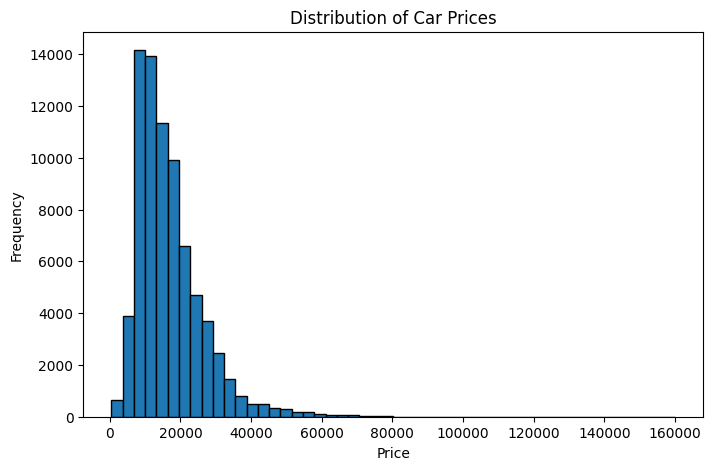

In [437]:
plt.figure(figsize=(8, 5))
plt.hist(df["price"].dropna(), bins=50, edgecolor="black")
plt.title("Distribution of Car Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

In [438]:
df["price"].describe()

count     75973.000000
mean      16881.889553
std        9736.926322
min         450.000000
25%       10200.000000
50%       14699.000000
75%       20950.000000
max      159999.000000
Name: price, dtype: float64

In [439]:
ordenado = df.sort_values("price", ascending=True)

baratos = ordenado[["Brand", "model", "year", "price"]].head(5)
caros = baratos[["Brand", "model", "year", "price"]].tail(5)
display(baratos)
display(caros)
#acho possível estes carros em especifico terem estes preços

,Brand,model,year,price
carID,,,,
60156,Opel,AGILA,2003.0,450
19562,Ford,FOCUS,2003.0,495
23427,Ford,FOCUS,2003.0,495
61005,Opel,CORSA,2002.0,495
55950,Opel,CORSA,2003.0,590


,Brand,model,year,price
carID,,,,
60156,Opel,AGILA,2003.0,450
19562,Ford,FOCUS,2003.0,495
23427,Ford,FOCUS,2003.0,495
61005,Opel,CORSA,2002.0,495
55950,Opel,CORSA,2003.0,590


In [440]:
def preco_no_fim(df):
    df = df.copy()

    df = df[[col for col in df.columns if col != "price"] + ["price"]]
    return df

In [441]:
df=preco_no_fim(df)
df

,Brand,model,year,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage,price
carID,,,,,,,,,,,,,
69512,VW,GOLF,2016.0,Semi-Auto,28421.0,Petrol,NaN,11.417268,2.0,63.0,4.000000,0.0,22290
53000,Toyota,YARIS,2019.0,Manual,4589.0,Petrol,145.0,47.900000,1.5,50.0,1.000000,0.0,13790
6366,Audi,Q2,2019.0,Semi-Auto,3624.0,Petrol,145.0,40.900000,1.5,56.0,4.000000,0.0,24990
29021,Ford,FIESTA,2018.0,anual,9102.0,Petrol,145.0,65.700000,1.0,50.0,-2.340306,0.0,12500
10062,BMW,2SERIES,2019.0,Manual,1000.0,Petrol,145.0,42.800000,1.5,97.0,3.000000,0.0,22995
...,...,...,...,...,...,...,...,...,...,...,...,...,...
37194,Mercedes,CCLASS,2015.0,Manual,14480.0,etrol,125.0,53.300000,2.0,78.0,0.000000,0.0,13498
6265,Audi,Q3,2013.0,Semi-Auto,52134.0,Diesel,200.0,47.900000,2.0,38.0,2.000000,0.0,12495
54886,Toyota,AYGO,2017.0,Automatic,11304.0,Petrol,145.0,67.000000,1.0,57.0,3.000000,0.0,8399


In [442]:
df["transmission"].unique()

array(['Semi-Auto', 'Manual', 'anual', 'Semi-Aut', 'Automatic', 'manual',
       nan, 'unknown', 'Manua', 'AUTOMATIC', 'MANUAL', 'semi-auto',
       ' Manual ', 'automatic', 'emi-Auto', 'SEMI-AUTO', 'SEMI-AUT',
       'Automati', 'ANUAL', 'utomatic', 'unknow', 'EMI-AUTO', 'manua',
       'anua', 'emi-Aut', 'MANUA', 'emi-auto', 'UTOMATIC', ' manual ',
       ' MANUAL ', 'UNKNOWN', 'nknown', 'automati', 'Other', 'semi-aut',
       ' Manual', 'AUTOMATI', 'utomati', 'Manual ', 'manual ', 'nknow'],
      dtype=object)

In [443]:
df[df["transmission"].isna()]

,Brand,model,year,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage,price
carID,,,,,,,,,,,,,
35317,Mercedes,CCLASS,2019.0,NaN,9463.0,Petrol,NaN,NaN,1.5,87.0,1.0,0.0,26176
35376,Mercedes,CCLASS,2015.0,NaN,43883.0,Diesel,125.0,60.1,2.1,54.0,0.0,0.0,16998
64396,Opel,ASTRA,2015.0,NaN,NaN,Diesel,0.0,78.5,1.6,61.0,2.0,0.0,6995
68423,VW,POLO,NaN,NaN,26941.0,Petrol,145.0,60.1,1.2,97.0,4.0,0.0,10328
47887,Skoda,FABIA,2020.0,NaN,835.0,Petrol,145.0,47.1,1.0,55.0,3.0,0.0,11990
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2368,Audi,Q2,2019.0,NaN,1500.0,Petrol,145.0,47.1,1.0,92.0,2.0,0.0,19990
12874,BMW,4SERIES,2019.0,NaN,999.0,Diesel,145.0,53.3,3.0,64.0,0.0,0.0,29995
1016,Audi,Q5,2016.0,NaN,28000.0,Diesel,200.0,NaN,2.0,42.0,4.0,0.0,22995


In [444]:
def HELPER_normalize_transmission(df):
    df = df.copy()
    df["transmission"] = (
        df["transmission"]
        .astype(str)
        .str.strip()
        .str.upper()
        .replace(["", "NAN", "NONE"], np.nan)
    )
    return df

In [445]:
def HELPER_transmissao_correta(transm, valid_list, threshold):
    if pd.isna(transm):
        return np.nan

    if transm in valid_list:
        return transm
    
    result = process.extractOne(transm, valid_list, scorer=fuzz.token_sort_ratio)
    if result is None:
        return np.nan

    match_name, score, _ = result
    return match_name if score >= threshold else np.nan

def fuzzy_transmissao(df, threshold=60):
    df = HELPER_normalize_transmission(df)
    valid_list = ["MANUAL", "AUTOMATIC", "SEMI-AUTO", "OTHER", "UNKNOWN"]

    df["transmission"] = df["transmission"].apply(
        lambda x: HELPER_transmissao_correta(x, valid_list, threshold)
    )
    return df

In [446]:
df = fuzzy_transmissao(df)
df[df["transmission"].isna()]

,Brand,model,year,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage,price
carID,,,,,,,,,,,,,
35317,Mercedes,CCLASS,2019.0,NaN,9463.0,Petrol,NaN,NaN,1.5,87.0,1.0,0.0,26176
35376,Mercedes,CCLASS,2015.0,NaN,43883.0,Diesel,125.0,60.1,2.1,54.0,0.0,0.0,16998
64396,Opel,ASTRA,2015.0,NaN,NaN,Diesel,0.0,78.5,1.6,61.0,2.0,0.0,6995
68423,VW,POLO,NaN,NaN,26941.0,Petrol,145.0,60.1,1.2,97.0,4.0,0.0,10328
47887,Skoda,FABIA,2020.0,NaN,835.0,Petrol,145.0,47.1,1.0,55.0,3.0,0.0,11990
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2368,Audi,Q2,2019.0,NaN,1500.0,Petrol,145.0,47.1,1.0,92.0,2.0,0.0,19990
12874,BMW,4SERIES,2019.0,NaN,999.0,Diesel,145.0,53.3,3.0,64.0,0.0,0.0,29995
1016,Audi,Q5,2016.0,NaN,28000.0,Diesel,200.0,NaN,2.0,42.0,4.0,0.0,22995


In [447]:
df["transmission"].unique()

array(['SEMI-AUTO', 'MANUAL', 'AUTOMATIC', nan, 'UNKNOWN', 'OTHER'],
      dtype=object)

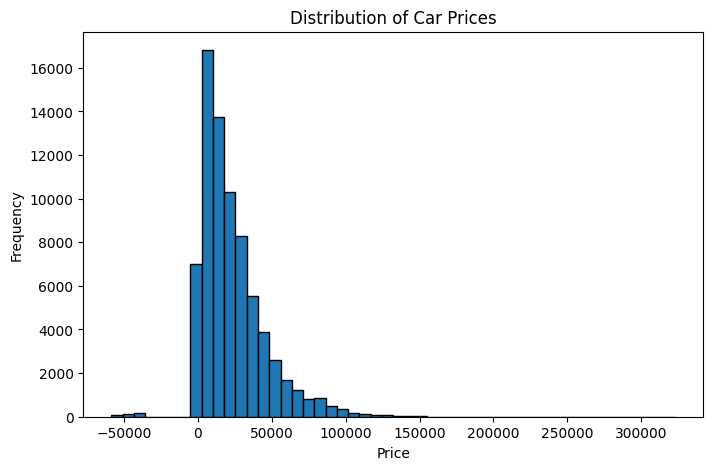

In [448]:
plt.figure(figsize=(8, 5))
plt.hist(df["mileage"].dropna(), bins=50, edgecolor="black")
plt.title("Distribution of Car Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()